In [1]:
# Import Libraries
import pandas as pd
import numpy as np

In [3]:
# Load Dataset
df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

In [4]:
# Risk Free Rate
annual_rf = 0.065

daily_rf = annual_rf / 252

In [6]:
# Calculate Sharpe Ratio
results = []

for amfi_code, group in df.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    std_return = group["daily_return"].std()

    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    results.append({
        "amfi_code": amfi_code,
        "Mean_Daily_Return": mean_return,
        "Std_Dev": std_return,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(results)

In [7]:
# Rank Funds
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df)+1)

In [8]:
# View Result
print(sharpe_df.head(10))

    amfi_code  Mean_Daily_Return   Std_Dev  Sharpe_Ratio  Rank
34     148567           0.001074  0.008941      1.448291     1
30     120843           0.001082  0.010008      1.306744     2
36     148569           0.001124  0.011134      1.234930     3
19     119551           0.000917  0.008656      1.208267     4
25     120505           0.001161  0.012152      1.180101     5
38     149323           0.001055  0.011179      1.132122     6
2      100033           0.001080  0.011929      1.093699     7
9      118632           0.000865  0.008913      1.081659     8
3      101206           0.000852  0.009177      1.027213     9
24     120504           0.000843  0.009048      1.026524    10


In [9]:
# Save CSV
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio_ranking.csv",
    index=False
)

print("Sharpe Ratio ranking saved successfully!")

Sharpe Ratio ranking saved successfully!


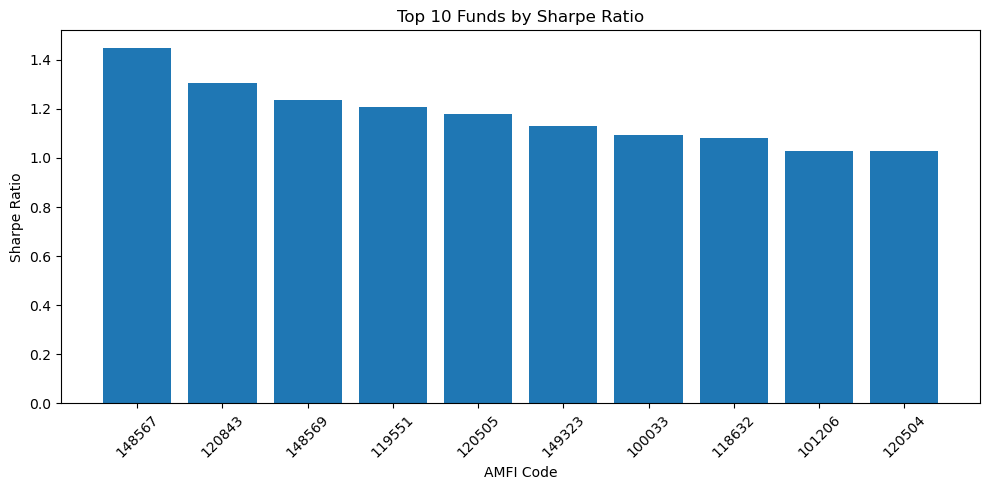

In [10]:
# Bar Chart
import matplotlib.pyplot as plt

top10 = sharpe_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")
plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/17_sharpe_ratio_top10.png")

plt.show()

In [11]:
## Insight

# The Sharpe Ratio ranks funds based on their risk-adjusted returns. Higher Sharpe Ratios indicate better returns for each unit of risk taken. The ranking highlights the best-performing mutual funds after accounting for volatility.